# CNN Optimizer Comparison: SGD vs Adam on CIFAR-10

**Question:** Implement a simple CNN and compare the performance of any two optimizers on the given image dataset.

---

## What are Optimizers?
After backpropagation computes *how wrong* each weight is, the **optimizer** decides *how to update* those weights.

### SGD (Stochastic Gradient Descent)
- The simplest optimizer — moves weights a fixed step size (learning rate) in the direction that reduces loss.
- We add `momentum=0.9` so it doesn't stop at shallow dips — it carries "momentum" like a ball rolling downhill.
- **Pros:** Simple, often generalizes well. **Cons:** Slow to converge, needs careful tuning.

### Adam (Adaptive Moment Estimation)
- Smarter optimizer — it tracks a *moving average* of past gradients and automatically adjusts the step size per weight.
- Weights that rarely update get bigger steps; weights that update often get smaller steps.
- **Pros:** Converges faster, less tuning needed. **Cons:** Can sometimes overfit more than SGD.

In [10]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

## Step 1 — Load and Preprocess the Data

We apply two transforms to every image:
1. **ToTensor**: Converts PIL image (0–255 integers) → float tensor (0.0–1.0)
2. **Normalize((0.5,), (0.5,))**: Shifts values so mean=0 and std=1, i.e., range becomes –1 to +1.
   - Formula: `(pixel - 0.5) / 0.5`
   - **Why?** Centered data helps the optimizer converge faster and more stably.

Note: We use the **full** CIFAR-10 dataset here (50k train, 10k test) so the comparison between optimizers is meaningful.

In [11]:
# Normalize each channel to mean=0.5, std=0.5 so pixel values end up in range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # one value per RGB channel
])

# Download CIFAR-10 dataset (auto-skips if already downloaded)
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# DataLoader batches the data and shuffles training data each epoch
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

## Step 2 — Define the CNN

### Architecture
```
Input image (3 × 32 × 32)
  → Conv1 (3→32 channels) + MaxPool   →  32 × 16 × 16
  → Conv2 (32→64 channels) + MaxPool  →  64 ×  8 ×  8
  → Flatten                           →  4096 values
  → FC1: 4096 → 128 + ReLU
  → FC2: 128  → 10  (class scores)
```

- **Conv2d**: Slides a small filter over the image to detect patterns (edges, shapes)
- **MaxPool2d(2,2)**: Shrinks spatial size by half — keeps only the strongest activation in each 2×2 area
- **view(-1, 4096)**: Flattens the 3D feature map to a 1D vector (`-1` means "infer batch size")
- **ReLU**: Applied only after the first FC layer — adds non-linearity so the network can learn complex patterns
- **No ReLU after Conv layers** in this simple model (adding it would improve accuracy)

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional layers: learn to detect visual features
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1)  # 32×32 → 32×32
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)  # 16×16 → 16×16
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial dimensions each time

        # Fully connected layers: classify based on detected features
        self.fc1  = nn.Linear(64 * 8 * 8, 128)  # 64 channels × 8×8 spatial = 4096 inputs
        self.fc2  = nn.Linear(128, 10)           # 10 outputs = 10 CIFAR-10 classes
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.conv1(x))    # Conv1 → Pool: 3×32×32  → 32×16×16
        x = self.pool(self.conv2(x))    # Conv2 → Pool: 32×16×16 → 64×8×8
        x = x.view(-1, 64 * 8 * 8)     # Flatten: 64×8×8 → 4096 (same as nn.Flatten)
        x = self.relu(self.fc1(x))      # Dense layer with ReLU activation
        x = self.fc2(x)                 # Final layer: raw scores for each class (no softmax needed)
        return x

## Step 3 — Training and Evaluation Function

We write one reusable function that:
1. Trains the model for `epochs` passes over the training data
2. After each epoch, evaluates on the test set
3. Records train loss, test loss, and test accuracy for plotting later

We run this function **twice** — once with SGD and once with Adam — on separate, fresh model instances so the comparison is fair.

In [13]:
def train_and_evaluate(model, criterion, optimizer, epochs=5):
    train_losses, test_losses, test_accs = [], [], []

    for epoch in range(epochs):

        # ── Training Phase ───────────────────────────────────────────────
        model.train()      # Enable training mode
        running_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()              # Clear old gradients
            outputs = model(images)            # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()                    # Backpropagate
            optimizer.step()                   # Update weights
            running_loss += loss.item()

        # ── Evaluation Phase ─────────────────────────────────────────────
        model.eval()  # Disable dropout/batchnorm training behavior
        test_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():  # No gradient computation needed
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

                # argmax picks the class with the highest score
                predicted = outputs.argmax(dim=1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        # ── Record and Print ─────────────────────────────────────────────
        avg_train_loss = running_loss / len(train_loader)
        avg_test_loss  = test_loss    / len(test_loader)
        accuracy       = correct / total

        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        test_accs.append(accuracy)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.2f}")

    return train_losses, test_losses, test_accs

In [14]:
# Create two separate models so each optimizer starts from the same architecture
model_sgd  = SimpleCNN()
model_adam = SimpleCNN()

criterion = nn.CrossEntropyLoss()  # Combines softmax + negative log-likelihood; standard for classification

# SGD with momentum=0.9: classic optimizer, momentum prevents getting stuck
optimizer_sgd  = optim.SGD(model_sgd.parameters(),  lr=0.01,  momentum=0.9)
# Adam: adaptive optimizer, adjusts learning rate per parameter automatically
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

print("=== Training with SGD ===")
train_loss_sgd,  test_loss_sgd,  acc_sgd  = train_and_evaluate(model_sgd,  criterion, optimizer_sgd)

print("\n=== Training with Adam ===")
train_loss_adam, test_loss_adam, acc_adam = train_and_evaluate(model_adam, criterion, optimizer_adam)

=== Training with SGD ===
Epoch 1/5 | Train Loss: 1.4728 | Test Loss: 1.1601 | Accuracy: 0.59
Epoch 2/5 | Train Loss: 1.0445 | Test Loss: 1.0158 | Accuracy: 0.65
Epoch 3/5 | Train Loss: 0.8674 | Test Loss: 0.9241 | Accuracy: 0.68
Epoch 4/5 | Train Loss: 0.7314 | Test Loss: 0.9241 | Accuracy: 0.69
Epoch 5/5 | Train Loss: 0.6126 | Test Loss: 0.9912 | Accuracy: 0.68

=== Training with Adam ===
Epoch 1/5 | Train Loss: 1.2963 | Test Loss: 1.0284 | Accuracy: 0.63
Epoch 2/5 | Train Loss: 0.9163 | Test Loss: 0.9407 | Accuracy: 0.67
Epoch 3/5 | Train Loss: 0.7451 | Test Loss: 0.8780 | Accuracy: 0.70
Epoch 4/5 | Train Loss: 0.6072 | Test Loss: 0.9112 | Accuracy: 0.70
Epoch 5/5 | Train Loss: 0.4843 | Test Loss: 0.9849 | Accuracy: 0.70


## Step 4 — Compare the Two Optimizers

We plot two side-by-side charts:
- **Left:** Training and test loss for both optimizers — lower is better; gap between train/test indicates overfitting
- **Right:** Test accuracy — higher is better

**What to look for:**
- Adam typically converges faster (steeper drop in early epochs)
- SGD with momentum often catches up and can generalize as well or better

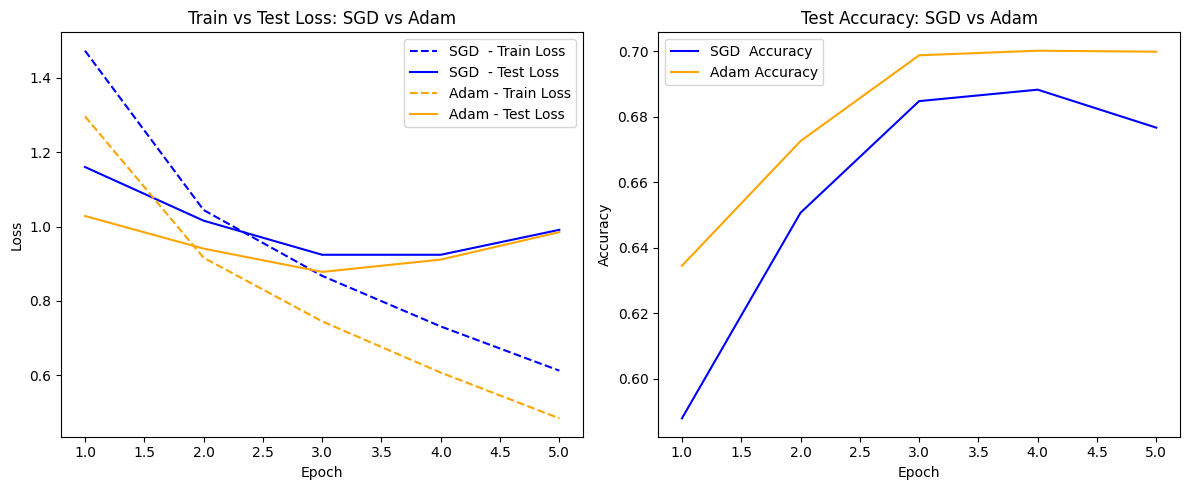

In [15]:
epochs = range(1, 6)  # x-axis: epoch numbers 1 to 5

plt.figure(figsize=(12, 5))

# ── Left Plot: Loss Comparison ───────────────────────────────────────────────
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_sgd,  label='SGD  - Train Loss',  linestyle='--', color='blue')
plt.plot(epochs, test_loss_sgd,   label='SGD  - Test Loss',   linestyle='-',  color='blue')
plt.plot(epochs, train_loss_adam, label='Adam - Train Loss',  linestyle='--', color='orange')
plt.plot(epochs, test_loss_adam,  label='Adam - Test Loss',   linestyle='-',  color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Test Loss: SGD vs Adam')
plt.legend()

# ── Right Plot: Accuracy Comparison ─────────────────────────────────────────
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_sgd,  label='SGD  Accuracy', color='blue')
plt.plot(epochs, acc_adam, label='Adam Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy: SGD vs Adam')
plt.legend()

plt.tight_layout()  # Prevent plots from overlapping
plt.show()